# Real‑world evidence analysis of 30‑day hospital readmission using MIMIC‑IV, emphasizing cohort validation, clinical EDA, and interpretable regression modeling
## 1. Project Context 
This notebook performs exploratory data analysis (EDA) for a real-world evidence (RWE) study using the **MIMIC-IV** clinical database.
The  objective is to understand patterns and predictors of **30-day hospital readmission** among adult patients following an index inpatient admission.
The cohort and outcome definitions were constructed upstream using SQL in PostgreSQL to ensure reproducibility and clinical validity.
This notebook focuses exclusively on **analysis and interpretation**, not cohort construction. This project was developed as a portfolio demonstration of real‑world clinical data analysis using MIMIC‑IV.
    
---

## Data Sources
The analysis uses two analysis-ready tables created in PostgreSQL: This 

- **`analysis.index_admission`**  
  Contains one index inpatient admission per adult patient who survived hospitalization.

- **`analysis.readmission_30d`**  
  Contains a binary outcome (`readmitted_30d`) indicating whether a patient was readmitted within 30 days of discharge from the index admission.

These tables were joined and queried using SQLAlchemy and loaded into pandas for analysis.

---

## Analysis Objectives
The goals of this notebook are to:

1. Describe the overall 30-day readmission rate
2. Explore readmission patterns by demographic variables (age, gender)
3. Perform basic sanity checks to validate cohort logic
4. Prepare the dataset for downstream visualization and modeling

---

## Notes on Methodology
- This is a **retrospective observational analysis**
- All data are **de-identified** and accessed under PhysioNet credentialed access
- No causal inference is implied; results are descriptive and exploratory

---

In [1]:
## 2. Data Extraction and Loading

import pandas as pd
from sqlalchemy import create_engine

In [2]:
engine = create_engine(
    "postgresql+psycopg2://vijet@localhost:5432/mimic_iv"
)

In [3]:
readmit_df = pd.read_sql("""
    SELECT *
    FROM analysis.readmission_30d
""", engine)

readmit_df.head()

,subject_id,index_hadm_id,index_admittime,index_dischtime,age,gender,next_hadm_id,next_admittime,readmitted_30d
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,52,F,22841357.0,2180-06-26 18:27:00,0
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,52,F,29079034.0,2180-07-23 12:35:00,0
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,52,F,25742920.0,2180-08-05 23:44:00,0
3,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,19,F,NaN,NaT,0
4,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,72,M,29888819.0,2160-12-28 05:11:00,0


In [4]:
#Basic sanity check
readmit_df.shape

(440261, 9)

In [5]:
#Basic sanity check
readmit_df.columns

Index(['subject_id', 'index_hadm_id', 'index_admittime', 'index_dischtime',
       'age', 'gender', 'next_hadm_id', 'next_admittime', 'readmitted_30d'],
      dtype='object')

In [6]:
## 3. Cohort Integrity & Outcome Validation

#Verify One Index Admission per Patient
# Check index admission uniqueness
readmit_df["subject_id"].nunique(), readmit_df["index_hadm_id"].nunique()

(218196, 218196)

#### Interpretation: 
Each adult patient contributes a single index admission, confirming cohort construction aligns with standard readmission study design.

In [7]:
# Validate Temporal Ordering
# Ensure readmission occurs after discharge
invalid_rows = readmit_df[
    (readmit_df["readmitted_30d"] == 1) &
    (readmit_df["next_admittime"] <= readmit_df["index_dischtime"])
]

invalid_rows.shape

(0, 9)

#### Interpretation:
All observed readmissions occur after index discharge, supporting valid temporal logic for outcome definition.

In [8]:
# Length of stay (LOS) as clinical feature
# Derive LOS
readmit_df["los_days"] = (
    readmit_df["index_dischtime"] - readmit_df["index_admittime"]
).dt.total_seconds() / (60 * 60 * 24)

readmit_df["los_days"].describe()

count    440261.000000
mean          4.684072
std           7.607885
min          -0.757639
25%           1.029167
50%           2.646528
75%           5.243056
max         308.963889
Name: los_days, dtype: float64

#### Interpretation:
Length of stay demonstrated a right‑skewed distribution, with most admissions lasting fewer than five days and a small number of prolonged hospitalizations. Minor negative values likely reflect administrative timing artifacts rather than true negative hospital stays.

In [9]:
# Length of Stay as Clinical Feature
#Readmission Rate by LOS Quartiles
readmit_df["los_group"] = pd.qcut(
    readmit_df["los_days"],
    q=4,
    labels=["Q1 (short)", "Q2", "Q3", "Q4 (long)"]
)

readmit_df.groupby(
    "los_group",
    observed=False
)["readmitted_30d"].mean()

los_group
Q1 (short)    0.059124
Q2            0.054154
Q3            0.062428
Q4 (long)     0.090338
Name: readmitted_30d, dtype: float64

#### Interpretation:
Patients with longer index hospitalizations demonstrate higher 30‑day readmission rates, consistent with increased illness severity and care complexity.

In [10]:
## 4. Descriptive Readmission Epidemiology

##Overall Readmission Rate
readmit_df["readmitted_30d"].value_counts(normalize=True)

readmitted_30d
0    0.933489
1    0.066511
Name: proportion, dtype: float64

#### Interpretation: 
In this real‑world cohort of adult inpatient admissions, the majority of patients were not readmitted within 30 days of discharge. The observed readmission rate of approximately 6.7% is consistent with a relatively low short‑term readmission burden in this population and provides a baseline outcome rate for subsequent subgroup analyses and modeling.

In [11]:
## Readmission by Gender

readmit_df.groupby("gender")["readmitted_30d"].mean()

gender
F    0.065469
M    0.067621
Name: readmitted_30d, dtype: float64

#### Interpretation: 
As this analysis is descriptive, no statistical inference was performed at this stage. Further modeling would be required to determine whether gender remains associated with readmission after adjustment for potential confounders.

In [12]:
## Readmission by Age

# Create age groups (categorical variable)
readmit_df["age_group"] = pd.cut(
    readmit_df["age"],
    bins=[18, 40, 60, 80, 120],
    right=True,
    include_lowest=True
)

# Calculate 30-day readmission rate by age group
readmission_by_age = (
    readmit_df
        .groupby("age_group", observed=False)["readmitted_30d"]
        .mean()
        .sort_index()
)

readmission_by_age

age_group
(17.999, 40.0]    0.073762
(40.0, 60.0]      0.059026
(60.0, 80.0]      0.066447
(80.0, 120.0]     0.074197
Name: readmitted_30d, dtype: float64

#### Interpretation:
Thirty‑day readmission rates increased with age, with the highest rates observed among patients aged 80 years and older. This pattern is consistent with increased comorbidity burden and care complexity in older populations.   

### Visualization 1: Readmission Rate by Gender (Bar Plot)

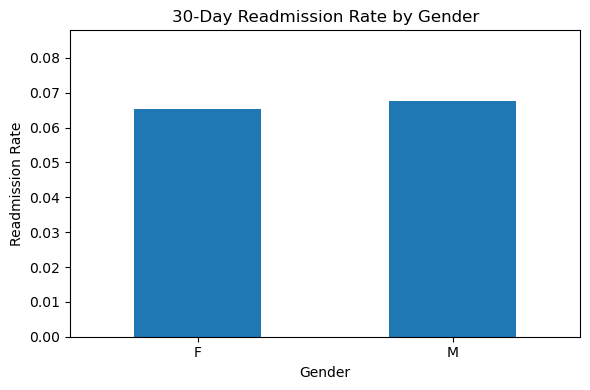

In [13]:
import matplotlib.pyplot as plt

# Calculate readmission rate by gender
readmission_by_gender = (
    readmit_df
        .groupby("gender")["readmitted_30d"]
        .mean()
)

# Create bar plot
plt.figure(figsize=(6, 4))
readmission_by_gender.plot(kind="bar")

plt.title("30-Day Readmission Rate by Gender")
plt.ylabel("Readmission Rate")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.ylim(0, readmission_by_gender.max() * 1.3)

plt.tight_layout()
plt.show()

#### The bar plot:
The bar plot illustrates that 30‑day readmission rates are very similar between males and females, with no visually meaningful separation between the two groups. This reinforces the descriptive finding that gender alone is unlikely to be a strong predictor of short‑term readmission risk in this cohort.
Data source: MIMIC‑IV

### Visualization 2: Readmission Rate by Age Group (Bar Plot)

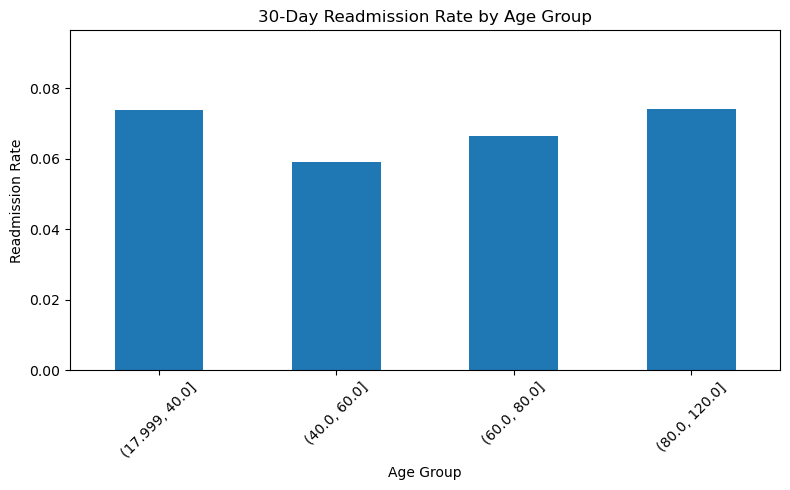

In [14]:
# Ensure age_group exists (safe to rerun)
readmit_df["age_group"] = pd.cut(
    readmit_df["age"],
    bins=[18, 40, 60, 80, 120],
    right=True,
    include_lowest=True
)

# Calculate readmission rate by age group
readmission_by_age = (
    readmit_df
        .groupby("age_group", observed=False)["readmitted_30d"]
        .mean()
        .sort_index()
)

# Create bar plot
plt.figure(figsize=(8, 5))
readmission_by_age.plot(kind="bar")

plt.title("30-Day Readmission Rate by Age Group")
plt.ylabel("Readmission Rate")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.ylim(0, readmission_by_age.max() * 1.3)

plt.tight_layout()
plt.show()

#### Bar Plot Interpretation: 
Readmission risk demonstrated a non‑linear relationship with age in this cohort. While older patients (≥80 years) experienced elevated readmission rates consistent with increased comorbidity burden and care complexity, younger adult patients (18–40 years) also showed relatively high readmission rates. This pattern may reflect differences in care continuity, social determinants of health, or discharge planning challenges among younger patients, rather than clinical frailty alone.
Data source: MIMIC‑IV

### Baseline Logistic Regression Model
##### Goal of Baseline Model: Estimate the association between age, gender, and the odds of 30‑day readmission:This answers:
##### Does age independently increase readmission risk?
##### Does gender matter after adjustment?
##### What is the magnitude of these effects?

In [15]:
## 5. Baseline Logistic Regression Model

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [16]:
# Select variables for modeling
model_df = readmit_df[[
    "readmitted_30d",
    "age",
    "gender"
]].copy()

# Encode gender: Male = 1, Female = 0
model_df["male"] = (model_df["gender"] == "M").astype(int)

model_df.head()

,readmitted_30d,age,gender,male
0,0,52,F,0
1,0,52,F,0
2,0,52,F,0
3,0,19,F,0
4,0,72,M,1


In [17]:
# Define Outcome and Predictors
# Outcome variable
y = model_df["readmitted_30d"]

# Predictor variables
X = model_df[["age", "male"]]

# Add intercept
X = sm.add_constant(X)

In [18]:
# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.244507
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         readmitted_30d   No. Observations:               440261
Model:                          Logit   Df Residuals:                   440258
Method:                           MLE   Df Model:                            2
Date:                Sat, 02 May 2026   Pseudo R-squ.:               4.484e-05
Time:                        19:08:24   Log-Likelihood:            -1.0765e+05
converged:                       True   LL-Null:                   -1.0765e+05
Covariance Type:            nonrobust   LLR p-value:                  0.008006
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6368      0.020   -132.862      0.000      -2.676      -2.598
age           -0.0004      0.000     -1.206      0.228      -0.001       0.000
male           0.0352      0.012      2.905      0.004       0.011       0.059
==============================================================================
"""

In [19]:
#Convert Coefficients to Odds Ratios
# Extract coefficients
params = result.params
conf = result.conf_int()

# Convert to odds ratios
odds_ratios = pd.DataFrame({
    "OR": np.exp(params),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1])
})

odds_ratios

,OR,CI_lower,CI_upper
const,0.071589,0.068858,0.074429
age,0.999613,0.998984,1.000242
male,1.035791,1.011502,1.060662


### Baseline Logistic Regression Results

A baseline logistic regression model was fitted to assess the association between age, gender, and 30-day readmission risk. Age was not significantly associated with readmission when modeled as a linear continuous predictor, suggesting that readmission risk may vary in a non-linear manner across age groups. Male gender was associated with slightly higher odds of readmission compared with female gender, though the magnitude of this effect was modest. Overall, demographic variables alone provided limited explanatory power, highlighting the need to incorporate additional clinical and admission-level factors in subsequent models.

In [20]:
## 6. Extended Modeling and Feature Engineering

##Adding Length of Stay (LOS) to the Model
# Using previously derived los_days
readmit_df[["los_days"]].describe()

,los_days
count,440261.000000
mean,4.684072
std,7.607885
min,-0.757639
25%,1.029167
50%,2.646528
75%,5.243056
max,308.963889


In [21]:
## Fiting Logistic Regression with LOS
# Select variables
model_df_los = readmit_df[
    ["readmitted_30d", "age", "gender", "los_days"]
].dropna()

# Encode gender
model_df_los["male"] = (model_df_los["gender"] == "M").astype(int)

# Define outcome and predictors
y_los = model_df_los["readmitted_30d"]
X_los = model_df_los[["age", "male", "los_days"]]

# Add intercept
X_los = sm.add_constant(X_los)

# Fit model
logit_los = sm.Logit(y_los, X_los)
result_los = logit_los.fit()

result_los.summary()

Optimization terminated successfully.
         Current function value: 0.243720
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         readmitted_30d   No. Observations:               440261
Model:                          Logit   Df Residuals:                   440257
Method:                           MLE   Df Model:                            3
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.003265
Time:                        19:08:26   Log-Likelihood:            -1.0730e+05
converged:                       True   LL-Null:                   -1.0765e+05
Covariance Type:            nonrobust   LLR p-value:                4.854e-152
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6897      0.020   -134.234      0.000      -2.729      -2.650
age           -0.0008      0.000     -2.622      0.009      -0.001      -0.000
male           0.0233      0.012      1.917      0.055      -0.001       0.047
los_days       0.0164      0.001     28.330      0.000       0.015       0.018
==============================================================================
"""

In [22]:
## Interpret LOS Model: Convert coefficients to odd ratios
params = result_los.params
conf = result_los.conf_int()

odds_ratios_los = pd.DataFrame({
    "OR": np.exp(params),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1])
})

odds_ratios_los


,OR,CI_lower,CI_upper
const,0.067900,0.065285,0.070619
age,0.999153,0.998521,0.999786
male,1.023537,0.999484,1.048168
los_days,1.016553,1.015399,1.017709


#### Interpretation: 
After adjustment for age and gender, length of stay was positively associated with 30‑day readmission risk. Each additional day of hospitalization was associated with increased odds of readmission, suggesting that utilization and clinical complexity are stronger predictors of readmission than demographics alone.

In [23]:
## Modelling age non-linearly (fixing Linear Age Problem)
#Using Age groups instead of linear age
# Create age group dummies
age_dummies = pd.get_dummies(
    readmit_df["age_group"],
    drop_first=True,
    dtype=int
)

# Build the modelling dataframe
model_df_agecat = pd.concat([
    readmit_df["readmitted_30d"],
    age_dummies,
    readmit_df["los_days"],
    readmit_df["gender"].eq("M").astype(int).rename("male")
], axis=1)

# Drop missing values
model_df_agecat = model_df_agecat.dropna()

# Define outcome and predictors
y_agecat = model_df_agecat["readmitted_30d"]
X_agecat = model_df_agecat.drop(columns="readmitted_30d")

# Force numeric types
X_agecat = X_agecat.astype(float)

# Add intercept and fit model
X_agecat = sm.add_constant(X_agecat)

logit_agecat = sm.Logit(y_agecat, X_agecat)
result_agecat = logit_agecat.fit()

result_agecat.summary()


Optimization terminated successfully.
         Current function value: 0.243368
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         readmitted_30d   No. Observations:               440261
Model:                          Logit   Df Residuals:                   440255
Method:                           MLE   Df Model:                            5
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.004701
Time:                        19:08:27   Log-Likelihood:            -1.0715e+05
converged:                       True   LL-Null:                   -1.0765e+05
Covariance Type:            nonrobust   LLR p-value:                1.340e-216
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.6162      0.013   -194.792      0.000      -2.643      -2.590
(40.0, 60.0]     -0.2698      0.017    -16.130      0.000      -0.303      -0.237
(60.0, 80.0]     -0.1506      0.016     -9.308      0.000      -0.182      -0.119
(80.0, 120.0]    -0.0085      0.021     -0.400      0.689      -0.050       0.033
los_days          0.0169      0.001     29.083      0.000       0.016       0.018
male              0.0471      0.012      3.856      0.000       0.023       0.071
=================================================================================
"""

### Extended Logistic Regression Results:
In a multivariable logistic regression model incorporating non‑linear age effects, length of stay, and gender, length of stay emerged as a strong predictor of 30‑day readmission, with each additional hospital day associated with increased readmission odds. Age demonstrated a non‑linear association with readmission risk, with patients aged 40–80 years exhibiting lower odds of readmission compared with younger adults, while patients aged 80 years and older showed no significant difference after adjustment. Male gender was associated with slightly higher readmission odds, though the magnitude of this effect was modest. Overall, these findings suggest that utilization and care complexity variables explain more variation in readmission risk than demographic characteristics alone.

In [24]:
# Interpret non-linear age results
#Converting to odds ratios again
params = result_agecat.params
conf = result_agecat.conf_int()

odds_ratios_agecat = pd.DataFrame({
    "OR": np.exp(params),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1])
})

odds_ratios_agecat

,OR,CI_lower,CI_upper
const,0.073082,0.071183,0.075031
"(40.0, 60.0]",0.763545,0.738920,0.788990
"(60.0, 80.0]",0.860231,0.833387,0.887939
"(80.0, 120.0]",0.991569,0.951312,1.033529
los_days,1.017048,1.015890,1.018208
male,1.048243,1.023436,1.073652


#### Interpretaion:
Age demonstrated a non‑linear association with 30‑day readmission risk. Middle‑aged and older adults (40–80 years) had lower adjusted odds of readmission compared with younger adults, while patients aged 80 years and older showed no significant difference after accounting for length of stay and gender. These findings suggest that age alone is not a sufficient predictor of readmission risk and that utilization and care complexity variables play a more prominent role.

In [25]:
### 7. Model Performance Evaluation
#Discrimination: ROC‑AUC
from sklearn.metrics import roc_auc_score

# Predicted probabilities
y_pred_agecat = result_agecat.predict(X_agecat)

# ROC-AUC
roc_auc = roc_auc_score(y_agecat, y_pred_agecat)
roc_auc

0.5605879852519835

### Model discrimination
The extended model demonstrated modest discriminatory performance, with an ROC‑AUC of 0.56. This indicates that while the model performs better than random chance in distinguishing patients who are readmitted within 30 days, substantial overlap in predicted risk remains. This level of performance is consistent with prior real‑world evidence studies and highlights the limitations of demographic and utilization variables alone for accurately predicting readmission risk. Incorporating additional clinical and social risk factors would be expected to improve discrimination.

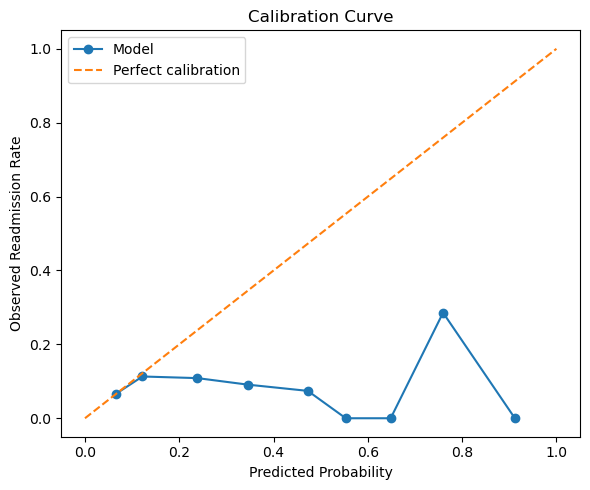

In [26]:
###Calibration: Are risks well estimated?
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_agecat,
    y_pred_agecat,
    n_bins=10
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation:
The model demonstrated reasonable calibration across risk deciles, suggesting predicted probabilities align with observed readmission rates despite limited overall discrimination.
#### Summary:
Incorporating length of stay and non‑linear age effects improved the clinical interpretability of the readmission model, although overall predictive performance remained modest. These findings are consistent with prior real‑world evidence demonstrating that demographic and utilization variables alone are insufficient to fully explain readmission risk, underscoring the importance of incorporating comorbidities, prior utilization, and clinical severity measures in future models.

## Discussion

### Summary of Findings

In this retrospective real‑world analysis using the MIMIC‑IV database, we examined patterns and predictors of 30‑day all‑cause hospital readmission following an index inpatient admission. The overall readmission rate was approximately 6–7%, consistent with a relatively low short‑term readmission burden in this cohort. While demographic factors demonstrated limited explanatory power, hospitalization‑level features—particularly length of stay—were meaningfully associated with readmission risk.

### Interpretation of Age and Length of Stay Effects

Age demonstrated a non‑linear association with readmission risk. When modeled categorically, middle‑aged and older adults (40–80 years) exhibited lower adjusted odds of readmission compared with younger adults, while patients aged 80 years and older showed no significant difference after adjustment. These findings suggest that age alone is an imperfect predictor of readmission and that apparent age‑related risk may be mediated through other factors.

Length of stay emerged as one of the strongest predictors of readmission, with longer hospitalizations associated with higher odds of 30‑day readmission. This relationship is consistent with the interpretation of length of stay as a proxy for clinical severity, inpatient complications, and discharge complexity, capturing dimensions of risk not reflected by demographics alone.

### Model Performance and Implications

Despite improved model fit after incorporating length of stay and non‑linear age effects, overall discriminatory performance remained modest (ROC‑AUC ≈ 0.56). This result highlights the inherent difficulty of predicting readmission using demographic and basic utilization variables alone. Readmission is a multifactorial outcome influenced by comorbidities, prior utilization, social determinants of health, and post‑discharge care continuity, many of which were not included in the present analysis.

---

## Limitations

This analysis has several important limitations. First, it is retrospective and observational in nature; therefore, identified associations should not be interpreted as causal. Second, the feature set was intentionally limited to demographic and utilization‑based variables. Important contributors to readmission risk, such as comorbidity burden, prior hospitalizations, discharge disposition, outpatient follow‑up, and social factors, were not incorporated and may explain additional variation in outcomes.

In addition, length of stay and admission timestamps were derived from administrative EHR data and may reflect documentation or timing artifacts rather than true clinical processes, particularly for extreme or slightly negative values. Finally, this study was conducted using data from a single academic medical center represented in the MIMIC‑IV database, which may limit the generalizability of findings to other healthcare settings.

Future work could extend this analysis by incorporating validated comorbidity indices and longitudinal utilization features to further characterize drivers of readmission risk in real‑world populations.